# Mérési notebook
---
# **1. mérési fázis**. A	Modellek tesztelése tanítás nélkül.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 7. modell **NASNet** modell tanítás nélküli tesztelése

#### A  NASNet@ImageNet1k modell tanítás nélküli futtatása a saját ImageNet180K adathalmaz Test részhalmazán. (teszt elemszám: 18k).


---



✅ 1. Telepítés + GPU ellenőrzés

In [ ]:
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn

import torch
if torch.cuda.is_available():
    print("✅ GPU aktív:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Nincs GPU! Runtime > Change runtime type > GPU")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 183.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 197.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 171.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 163.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 214.3 MB/s eta 0:00:00
✅ GPU aktív: NVIDIA L4


✅ 2. Drive csatolás + ZIP kicsomagolás (ha kell)

In [ ]:
from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("📁 Kicsomagolva:", extract_path)


Mounted at /content/drive
📁 Kicsomagolva: /content/imagenet_splitted_db


✅ 3. Modell, adatbetöltés, predikció (timm NASNet)

In [ ]:
import timm
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import time
from tqdm import tqdm

# Paraméterek
batch_size = 64
num_workers = 2
test_dir = "/content/imagenet_splitted_db/imagenet_splitted_db/test"

# Transzformáció NASNet-hez (331x331)
transform = transforms.Compose([
    transforms.Resize(360),
    transforms.CenterCrop(331),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Adatbetöltés
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# NASNet-A-Large modell betöltése
model = timm.create_model('nasnetalarge', pretrained=True)
model.eval().cuda()

# Predikciók
all_preds, all_probs, all_labels = [], [], []

start_time = time.perf_counter()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference"):
        inputs = inputs.cuda()
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

end_time = time.perf_counter()
inference_time = end_time - start_time


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/356M [00:00<?, ?B/s]

Inference: 100%|██████████| 284/284 [04:35<00:00,  1.03it/s]


✅ 4. Metrikák számítása – saját 114 osztályodra szűkítve

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score

# Kategórianév-leképezés (ImageNet 1k)
imagenet_classes_path = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
import urllib.request

with urllib.request.urlopen(imagenet_classes_path) as f:
    imagenet_categories = [line.decode("utf-8").strip() for line in f.readlines()]

imagenet_name_to_index = {name.lower(): idx for idx, name in enumerate(imagenet_categories)}
normalized_class_names = [name.replace("_", " ").lower() for name in test_dataset.classes]
imagenet_indices = [imagenet_name_to_index[name] for name in normalized_class_names]

# Szűkítés a saját 114 kategóriára
y_probs = np.array(all_probs)
y_probs_subset = y_probs[:, imagenet_indices]

y_true = np.array(all_labels)
y_pred = np.argmax(y_probs_subset, axis=1)

# Metrikák
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
top5 = top_k_accuracy_score(y_true, y_probs_subset, k=5)

print(f"\n🔍 Vizsgálat eredményei (NASNet-A-Large @ ImageNet1k, saját 114 osztály):")
print(f"✅ Top-1 Accuracy:  {accuracy:.4f}")
print(f"✅ Top-5 Accuracy:  {top5:.4f}")
print(f"🎯 Precision:       {precision:.4f}")
print(f"🎯 Recall:          {recall:.4f}")
print(f"🎯 F1-score:        {f1:.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Vizsgálat eredményei (NASNet-A-Large @ ImageNet1k, saját 114 osztály):
✅ Top-1 Accuracy:  0.2820
✅ Top-5 Accuracy:  0.5408
🎯 Precision:       0.3204
🎯 Recall:          0.2799
🎯 F1-score:        0.2696
⏱️ Inference time:  275.30 sec


✅ 5. Confusion Matrix, osztálystatisztika, CSV export

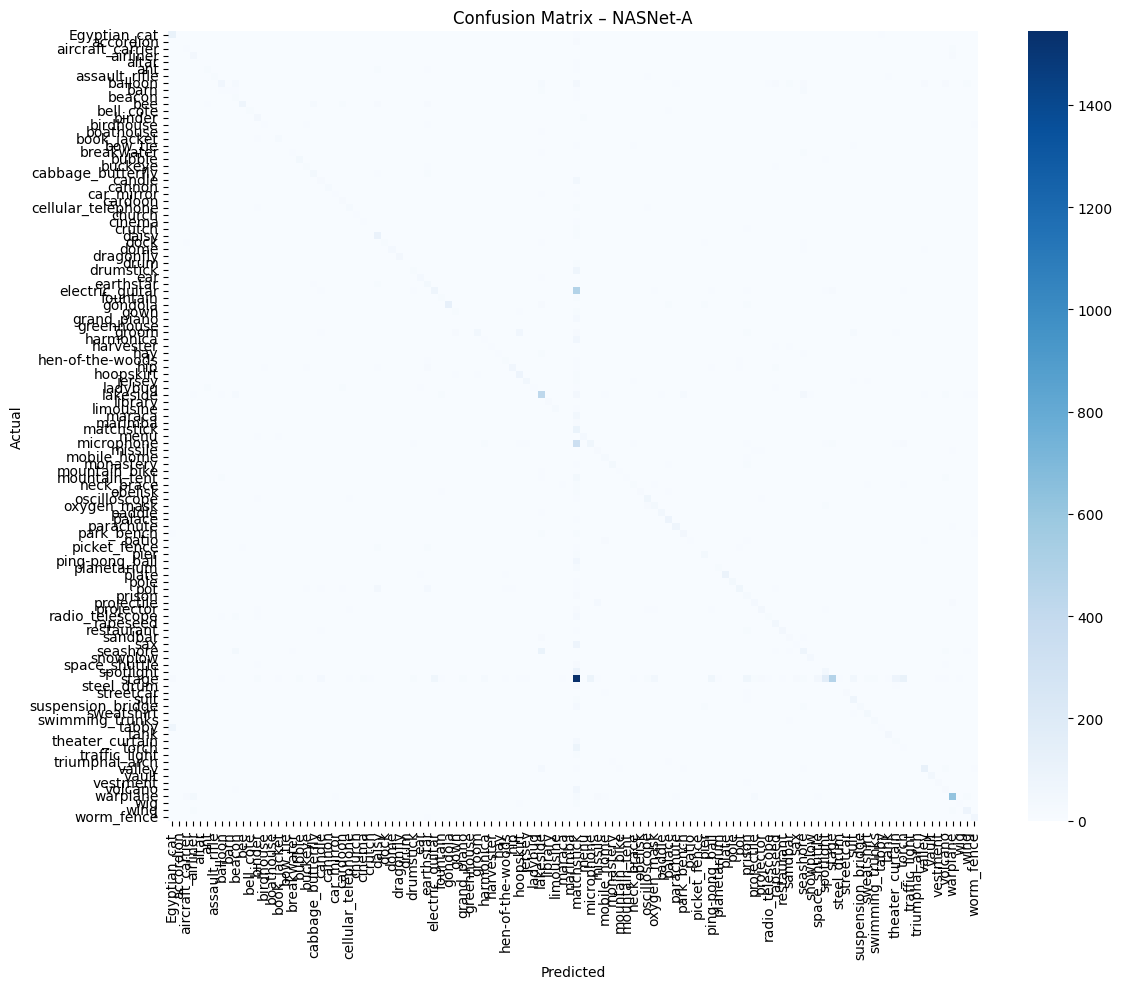


📋 Részletes osztályonkénti metrikák:

                    precision    recall  f1-score   support

      Egyptian_cat       0.39      0.75      0.51       145
         accordion       0.12      0.04      0.06        47
  aircraft_carrier       0.12      0.31      0.17        39
          airliner       0.31      0.56      0.40        80
             altar       0.24      0.10      0.14        59
               ant       0.13      0.14      0.13        95
     assault_rifle       0.41      0.14      0.21        91
           balloon       0.36      0.17      0.23       338
              barn       0.30      0.08      0.13       111
            beacon       0.07      0.21      0.10        62
               bee       0.72      0.36      0.48       212
         bell_cote       0.33      0.17      0.22        77
            binder       0.22      0.43      0.29       105
         birdhouse       0.18      0.09      0.12       116
         boathouse       0.17      0.12      0.14        43


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# Osztálynevek
class_names = test_dataset.classes

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – NASNet-A")
plt.tight_layout()
plt.show()

# Részletes metrikák
print("\n📋 Részletes osztályonkénti metrikák:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# CSV export
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1-score": f1_per_class,
})
df_metrics.to_csv("/content/nasnetalarge_test_metrics.csv", index=False)
print("📁 Mentve: nasnetalarge_test_metrics.csv")

# Legrosszabbul teljesítő osztályok
print("\n😢 Legrosszabbul teljesítő osztályok:")
print(df_metrics.sort_values("F1-score").head(10))


Kategória remapping ellenőrzés

In [ ]:
# --- 1. y_true / y_pred tartomány-ellenőrzés ---
print("✅ Index-tartomány ellenőrzés:")
print(f" - y_true: {np.min(y_true)} – {np.max(y_true)}")
print(f" - y_pred: {np.min(y_pred)} – {np.max(y_pred)}")
print(f" - y_probs_subset.shape: {y_probs_subset.shape}")

if np.max(y_true) >= len(class_names) or np.max(y_pred) >= len(class_names):
    print("⚠️ Figyelem: valamelyik index kilóg a 114 kategória tartományából!")
else:
    print("✅ Minden index a megfelelő tartományban van.")

print("\n📋 Kategória-párosítás ellenőrzés:")
print(f"{'Lokális index':<15} {'Mappanév (raw)':<30} {'Normalizált név':<30} {'ImageNet index':<15}")
print("-" * 95)
for i, (raw, norm, idx) in enumerate(zip(class_names, normalized_class_names, imagenet_indices)):
    print(f"{i:<15} {raw:<30} {norm:<30} {idx:<15}")


✅ Index-tartomány ellenőrzés:
 - y_true: 0 – 113
 - y_pred: 0 – 113
 - y_probs_subset.shape: (18172, 114)
✅ Minden index a megfelelő tartományban van.

📋 Kategória-párosítás ellenőrzés:
Lokális index   Mappanév (raw)                 Normalizált név                ImageNet index 
-----------------------------------------------------------------------------------------------
0               Egyptian_cat                   egyptian cat                   285            
1               accordion                      accordion                      401            
2               aircraft_carrier               aircraft carrier               403            
3               airliner                       airliner                       404            
4               altar                          altar                          406            
5               ant                            ant                            310            
6               assault_rifle                  assault rifle